# 02. Time-Series Analysis & Seasonality Decomposition

Analyzes diurnal (24h) and weekly (168h) periodicities across EV charging sites.

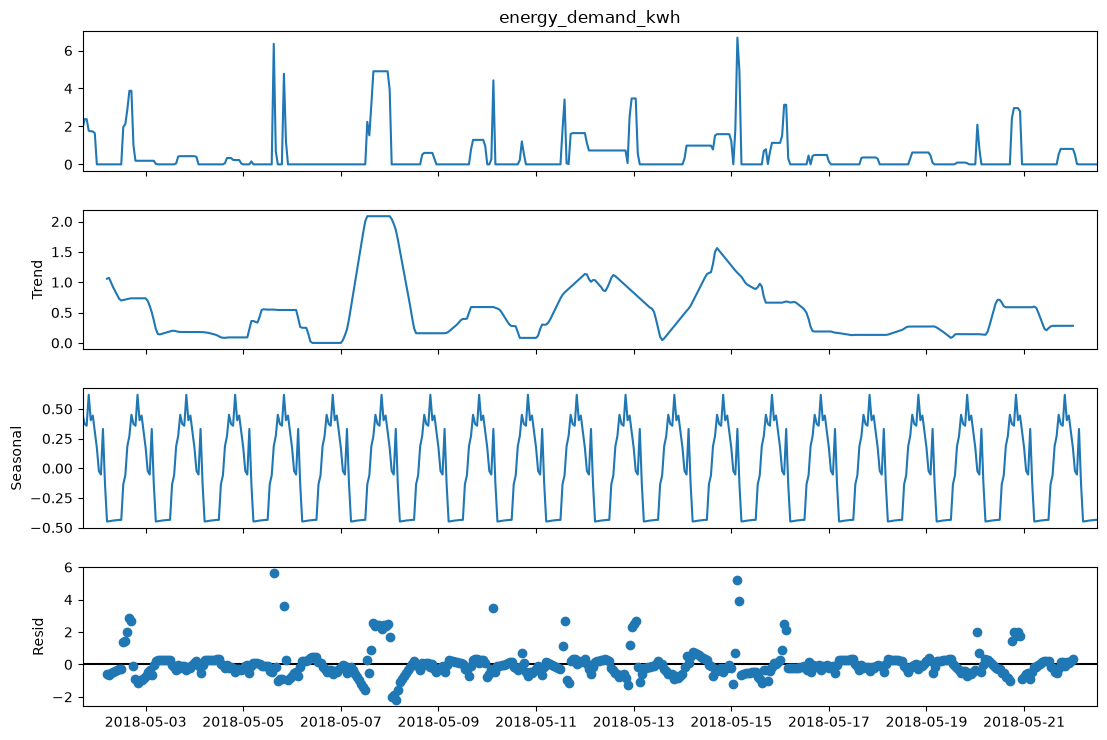

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

df_hourly = pd.read_parquet("../data/processed/hourly_demand.parquet")
sample_station = df_hourly["station_id"].iloc[0]
st_series = df_hourly[df_hourly["station_id"] == sample_station].set_index("timestamp")[
    "energy_demand_kwh"
]

decomp = seasonal_decompose(st_series.iloc[:500].fillna(0), model="additive", period=24)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.show()